# IIR introduction

In [281]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Une alternative au FIR

Utiliser FIR simple permet de créer un filtre: e.g.: $y[n] = 0.5.x[n]- 0.5.x[n-1]$.

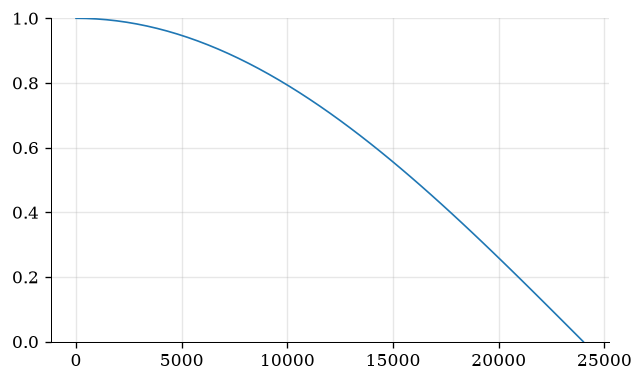

In [290]:
# load audio file
x, fs = wavread('assets/drums.wav')
t = np.arange(0, len(x)) / fs

# play input
playsound(x, fs)

# create filter
h = np.array([0.5, 0.5])
# n = 20; h = np.ones(n)/n

# get filter response
n = 100
H = np.fft.rfft(h, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot filter response
plt.plot(freqs, np.abs(H));
plt.ylim([0, 1]); plt.show()

# apply filter
y = np.convolve(x, h)

# play output
playsound(y, fs)

pour avoir un comportement plus marqué, il va falloir augmenter la taille du FIR

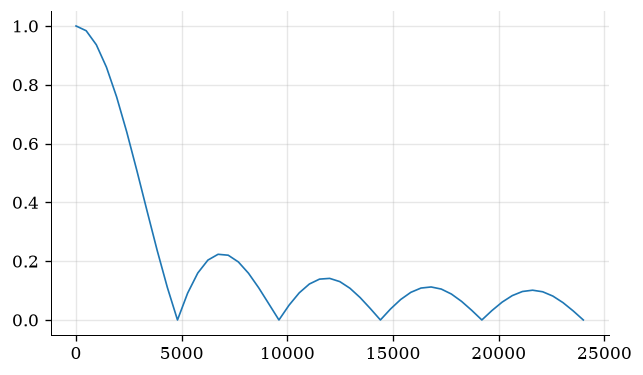

In [283]:
# load audio file
x, fs = wavread('assets/drums.wav')

# play input
playsound(x, fs)

# create filter
n = 10; h = np.ones(n)/n

# apply filter
y = np.convolve(x, h)

# get filter response
n = 100
H = np.fft.rfft(h, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot filter response
plt.plot(freqs, np.abs(H)); plt.show()

# play output
playsound(y, fs)

Utiliser une récursion permet d'avoir l'équivalent d'un FIR pour très peu de coefficients et donc d'opération: $y[n] = 0.1.x[n] + 0.9.y[n-1]$.

The FIR can only “remember” as many past samples as we explicitly give it coefficients for. The IIR reuses its previous output, so a single previous value carries information from arbitrarily far into the past.

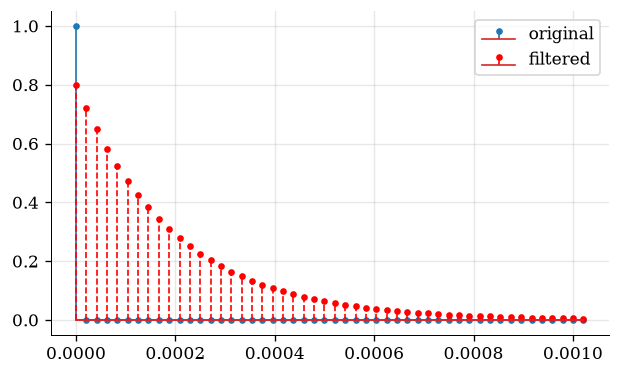

In [284]:
# filter
def filter(x, b, a):
    y = np.zeros_like(x)
    y[0] = b * x[0]
    for i_sample in range(1, len(x)):
        y[i_sample] = b * x[i_sample] - a * y[i_sample - 1]
    return y

# create input signal
x = np.zeros(50); x[0] = 1; t = np.arange(0, len(x))/fs

# filter
b = 0.8; a = -0.9
y = filter(x, b, a)

# plot
plt.stem(t, x, label = 'original')
plt.stem(t, y, '--r', label = 'filtered')
plt.legend(); plt.show();

équivalent en utilisant `lfilter`

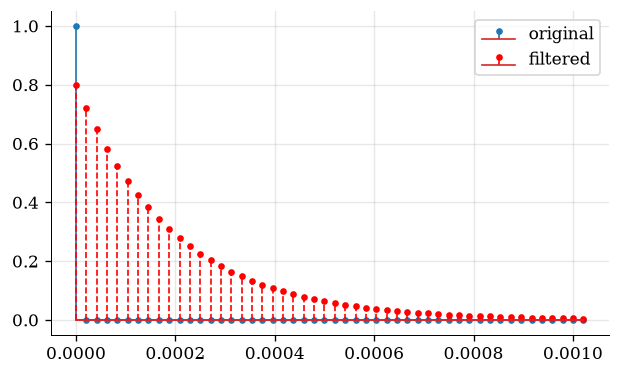

In [285]:
# filter
y = scipy.signal.lfilter([b], [1, a], x)

# plot
plt.stem(t, x, label = 'original')
plt.stem(t, y, '--r', label = 'filtered')
plt.legend(); plt.show();

c'est un IIR, qui permet pour un coup dérisoire (par rapport à convolution ou FFT + multiplication) d'obtenir des comportements très spécifiques.

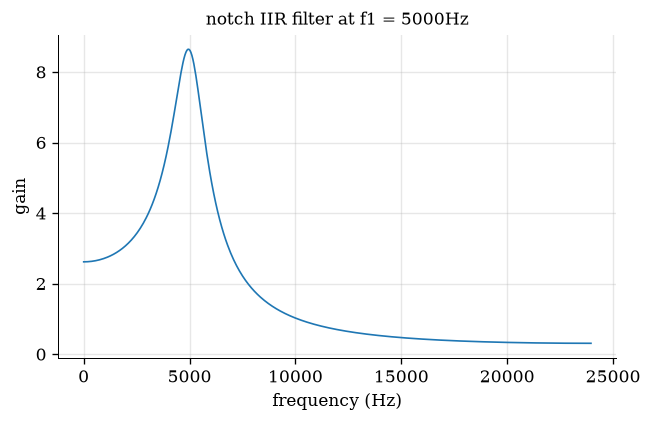

In [286]:
# load audio file
x, fs = wavread('assets/drums.wav')

# play
playsound(x, fs)

# filter
#  y[n] = x[n] + 2.r.cos(w0).y[n-1] - r^2 y[n-2]
f1 = 5000 # notch frequency
w0 = (f1/fs) * 2*math.pi; 
r = 0.9 # selectivity (please stay in 0:0.99)
a = [1, -2*r*math.cos(w0), r**2]
b = [1]
y = scipy.signal.lfilter(b, a, x)

# charaterise filter
freqs, H = scipy.signal.freqz(b, a, fs=fs)

# plot
plt.plot(freqs, np.abs(H))
plt.xlabel('frequency (Hz)'); plt.ylabel('gain'); 
plt.title(f'notch IIR filter at f1 = {f1}Hz'); 
plt.show()

# play
playsound(y, fs)

## Use cookbooks

there is a whole cookbook on how to find coefficients, for now let's use toolboxes

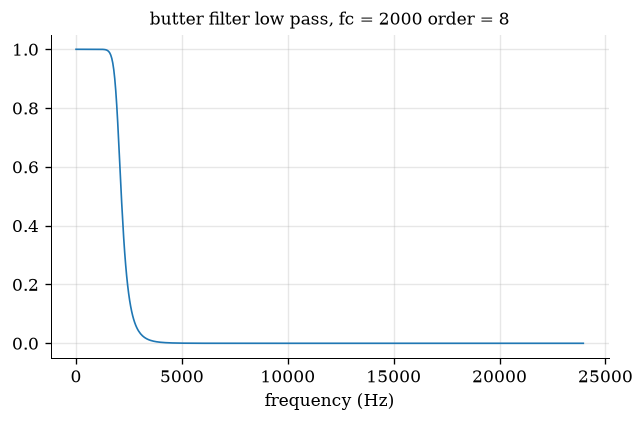

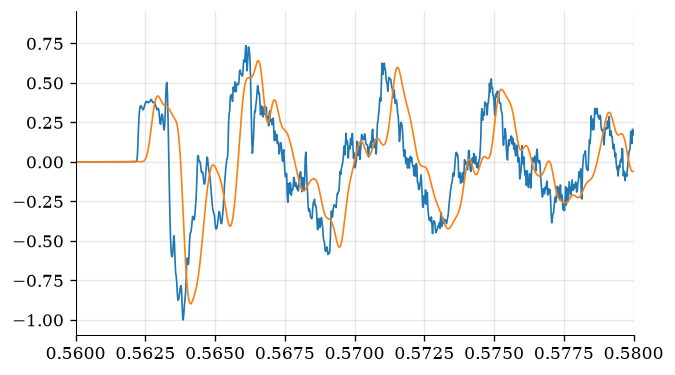

In [287]:
# define filter
btype = 'low'; ftype = 'butter'; Wn = 2000; order = 8
# btype = 'high'; ftype = 'butter'; Wn = 4000; order = 4
# btype = 'bandpass'; ftype = 'butter'; Wn = [2000, 4000]; order = 4
# btype = 'bandstop'; ftype = 'butter'; Wn = [300, 700]; order = 4

# load audio file
x, fs = wavread('assets/drums.wav')

# play
playsound(x, fs)

# get filter coefficients
b, a = scipy.signal.iirfilter(N=order, Wn=Wn, fs=fs, btype=btype, ftype=ftype)

# plot frequency response
freqs, H = scipy.signal.freqz(b, a, fs=fs)
plt.plot(freqs, np.abs(H))
plt.xlabel('frequency (Hz)');
plt.title(f'{ftype} filter {btype} pass, fc = {Wn} order = {order}');
plt.show()

# filter signal 
y = scipy.signal.lfilter(b, a, x)

# play 
playsound(y, fs)

# plot
t = np.arange(0, len(x))/fs
plt.plot(t, x, label = 'original');
plt.plot(t, y, label = 'filtered');
plt.xlim([0.56, 0.58]); plt.show()

the same with zero phase

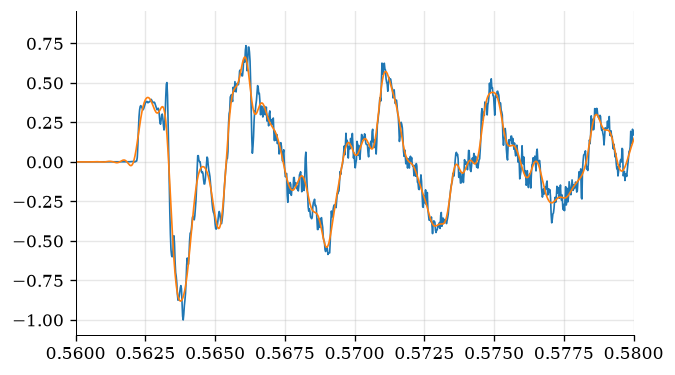

In [288]:
# apply filter forward and backward using filtfilt
y = scipy.signal.filtfilt(b, a, x)

# plot
t = np.arange(0, len(x))/fs
plt.plot(t, x, label = 'original');
plt.plot(t, y, label = 'filtered');
plt.xlim([0.56, 0.58]); plt.show()

## Interactive exploration Z plane 

https://dsp-workshop.nl/basics/pole-zero-explorer.html

## manual calculation of poles and zeros

## Compare FIR and IIR

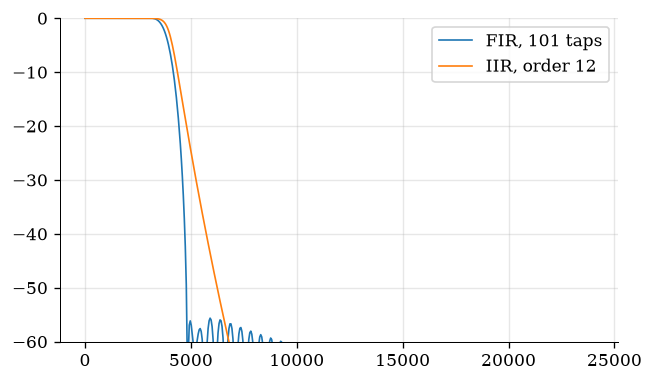

In [289]:
from scipy import signal

fs = 48000
fc = 4000

# FIR: needs many coefficients for a reasonably sharp LPF
numtaps = 101
b_fir = scipy.signal.firwin(
    numtaps=numtaps,
    cutoff=fc,
    fs=fs
)
a_fir = [1]

# IIR: Butterworth
order = 12
b_iir, a_iir = scipy.signal.butter(
    N=order,
    Wn=fc,
    btype='low',
    fs=fs
)

f, H_fir = signal.freqz(b_fir, a_fir, fs=fs)
f, H_iir = signal.freqz(b_iir, a_iir, fs=fs)

plt.plot(f, 20*np.log10(abs(H_fir)), label=f'FIR, {numtaps} taps')
plt.plot(f, 20*np.log10(abs(H_iir)), label=f'IIR, order {order}')
plt.ylim([-60, 0]); plt.legend(); plt.show()